# 04. Model Training

## Introduction

Model training is the process of teaching a machine learning algorithm to learn patterns and relationships from historical data. During this phase, the model uses the input features to understand how different factors influence the target variable.

In this project, multiple machine learning algorithms will be trained using the processed mental health dataset. The performance of these models will later be evaluated and compared to identify the most suitable model for depression risk prediction.

The trained model will serve as the foundation for prediction, explainability, and deployment in the later stages of the project.

---

## Objective

- Prepare the dataset for machine learning.
- Separate the features and target variable.
- Split the dataset into training and testing sets.
- Train multiple machine learning models.
- Save the trained models for further evaluation.

# 1. Features (X) and Target (y)

Machine learning models require the dataset to be divided into two components:

- **Features (X):** The input variables used by the model to learn patterns and relationships within the data.
- **Target (y):** The output variable that the model is trained to predict.

In this project, all processed columns except **Depression** are considered input features, while **Depression** serves as the target variable.

Separating the features and target variable ensures that the model learns from the input data without accessing the actual outcome during training, thereby preventing data leakage and enabling fair model evaluation.

---

## Objective

To separate the processed dataset into input features (`X`) and the target variable (`y`) for machine learning model training.

In [2]:
# Import required libraries
import pandas as pd

In [3]:
# Load the processed dataset
df = pd.read_csv("../Dataset/Processed/MindSense_AI_Cleaned_Dataset_v1.csv")

# Display first five rows
df.head()

,Gender,Age,Working Professional or Student,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,...,Degree_M.Tech,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_PhD
0,0,37,1,-1.0,2.0,-1.0,-1.0,4.0,2,1,...,0,1,0,0,0,0,0,0,0,0
1,1,60,1,-1.0,4.0,-1.0,-1.0,3.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,42,1,-1.0,2.0,-1.0,-1.0,3.0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,44,1,-1.0,3.0,-1.0,-1.0,5.0,2,2,...,0,0,0,0,0,1,0,0,0,0
4,1,48,1,-1.0,4.0,-1.0,-1.0,3.0,2,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Encode target variable
df["Depression"] = df["Depression"].map({
    "No": 0,
    "Yes": 1
})

In [5]:
# Separate input features
X = df.drop("Depression", axis=1)

# Separate target variable
y = df["Depression"]

In [6]:
# Display the shape of features and target
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2556, 107)
Shape of y: (2556,)


# 2. Train-Test Split

Machine learning models should be evaluated on data that was not used during training. Therefore, the dataset is divided into two subsets:

- **Training Set:** Used to train the machine learning model and learn patterns from the input data.
- **Testing Set:** Used to evaluate the model's performance on unseen data.

Separating the dataset into training and testing sets helps measure how well the model generalizes to new data and reduces the risk of overfitting.

---

## Objective

To split the dataset into training and testing subsets so that the machine learning model can be trained on one portion of the data and evaluated on unseen data.

## Why an 80:20 Train-Test Split?

An 80:20 train-test split is a commonly used approach in machine learning because it provides a good balance between model training and evaluation.

- **80% Training Data:** Allows the model to learn from a large number of samples and capture meaningful patterns.
- **20% Testing Data:** Provides sufficient unseen data to evaluate the model's performance and generalization ability.

Although 80:20 is a widely adopted practice, the split ratio may vary depending on the size of the dataset and the specific problem.

### Test Size (`test_size`)

The `test_size` parameter specifies the proportion of the dataset that should be reserved for testing the machine learning model.

For example:

- `test_size = 0.2` reserves **20%** of the dataset for testing and uses the remaining **80%** for training.
- `test_size = 0.3` reserves **30%** of the dataset for testing and uses **70%** for training.

Selecting an appropriate test size ensures that the model has sufficient data to learn meaningful patterns while retaining enough unseen data for reliable evaluation.

In this project, a **20% test size** is used because it provides a balanced split between training and testing data.

### Random State (`random_state`)

The `random_state` parameter controls the randomness of the train-test split.

By default, the dataset is randomly shuffled before splitting. As a result, running the same code multiple times may produce different training and testing datasets.

Setting a fixed value for `random_state` ensures that the same random split is generated every time the code is executed. This makes the experiment reproducible and allows consistent comparison of machine learning models.

In this project, `random_state=42` is used to ensure reproducible and consistent results.

### Stratified Sampling (`stratify`)

The `stratify` parameter ensures that the class distribution of the target variable is preserved in both the training and testing datasets.

For classification problems, the target variable may contain an unequal number of samples for each class. If the dataset is split randomly without stratification, the class proportions in the training and testing sets may differ from the original dataset, leading to biased model evaluation.

Using `stratify=y` maintains the same class distribution in both subsets, resulting in a more representative split and a more reliable evaluation of the machine learning model.

In this project, `stratify=y` is used to preserve the distribution of the **Depression** classes in both the training and testing datasets.

In [7]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (2044, 107)
X_test Shape  : (512, 107)
y_train Shape : (2044,)
y_test Shape  : (512,)


### Train-Test Split Output

The `train_test_split()` function returns four variables:

- **X_train:** Training features used to train the machine learning model.
- **X_test:** Testing features used to evaluate the trained model.
- **y_train:** Training target values corresponding to `X_train`.
- **y_test:** Testing target values corresponding to `X_test`.

During training, the model learns the relationship between `X_train` and `y_train`.

After training, the model makes predictions using `X_test`. These predictions are then compared with the actual target values (`y_test`) to evaluate the model's performance.

### Verify the Train-Test Split

After splitting the dataset, the shapes of the training and testing sets are displayed to verify that the split has been performed correctly.

- `X_train.shape` shows the number of training samples and features.
- `X_test.shape` shows the number of testing samples and features.
- `y_train.shape` shows the number of training target values.
- `y_test.shape` shows the number of testing target values.

Verifying the shapes helps ensure that:
- The dataset has been split according to the specified ratio.
- The number of feature columns remains unchanged.
- Each feature dataset has a corresponding target dataset.
- The data is ready for machine learning model training.

## 4.1 Logistic Regression

### Introduction

Logistic Regression is one of the most fundamental supervised machine learning algorithms used for **binary classification** problems.

Unlike linear regression, which predicts continuous numerical values, Logistic Regression predicts the **probability** that a data sample belongs to a particular class.

The predicted probability ranges from **0 to 1**. A threshold (commonly **0.5**) is then applied to convert the probability into one of the two class labels.

In this project, Logistic Regression is used to predict whether an individual is likely to experience **Depression (Yes/No)** based on the input features.

---

### Objective

To train a baseline Logistic Regression model for predicting depression and evaluate its performance on unseen data.

### The Sigmoid Function

The Sigmoid Function is the core mathematical function used in Logistic Regression.

Its purpose is to transform any real-valued input into a probability between **0 and 1**.

The output of the Sigmoid Function represents the probability that a data sample belongs to the positive class.

After computing this probability, a threshold (commonly **0.5**) is applied:

- If the probability is **greater than or equal to 0.5**, the sample is classified as the positive class.
- If the probability is **less than 0.5**, the sample is classified as the negative class.

The Sigmoid Function enables Logistic Regression to perform binary classification by converting continuous model outputs into probabilities.

### Weights in Logistic Regression

Weights represent the importance of each feature in making predictions.

Each feature has its own weight, and the model automatically learns these weights during training.

- A larger weight means the feature has a greater influence on the prediction.
- A smaller weight means the feature has less influence on the prediction.

The model learns the optimal weights from the training data to minimize prediction errors.

### Bias in Logistic Regression

Bias is an additional parameter added to the weighted sum of the input features.

It acts as an intercept, allowing the model to shift its predictions instead of always passing through zero.

Without the bias term, if all input features are zero, the model's output (`z`) will also be zero.

The bias provides flexibility and helps the model learn better decision boundaries from the training data.

The Logistic Regression equation is:

z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

where:

- `w` = Weights (importance of each feature)
- `x` = Input feature values
- `b` = Bias (intercept)

### Importing Logistic Regression

Scikit-learn is a popular Python library for Machine Learning.

The Logistic Regression algorithm is implemented inside the `linear_model` module of Scikit-learn.

Before using the algorithm, we must import it.

```python
from sklearn.linear_model import LogisticRegression
```

Here:

- `sklearn` → Scikit-learn library
- `linear_model` → Module containing linear algorithms
- `LogisticRegression` → Class used to create a Logistic Regression model

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

### Creating the Logistic Regression Model

After importing the `LogisticRegression` class, we create an instance of the model.

```python
model = LogisticRegression()
```

At this stage, the model is **not trained**.

It is simply an empty machine learning model with default parameters, ready to learn from the training data.

The actual learning happens when the `fit()` method is called.

### Training the Logistic Regression Model

The model is trained using the `fit()` method.

```python
model.fit(X_train, y_train)
```

Here:

- `X_train` contains the input features.
- `y_train` contains the corresponding target labels.

During training, the model learns the relationship between the input features and the target variable by finding the optimal weights and bias that minimize prediction errors.

This learning process is known as **Supervised Learning**, because the model learns using labeled data.

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

d:\MindSense-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Training the Model using `fit()`

The `fit()` method is responsible for training the Logistic Regression model.

```python
model.fit(X_train, y_train)
```

During training, the model:

1. Starts with initial weights and bias.
2. Uses the training features (`X_train`) to make predictions.
3. Compares the predictions with the actual target values (`y_train`).
4. Calculates the prediction error.
5. Adjusts the weights and bias to reduce the error.
6. Repeats the process until it finds the optimal parameters.

The learned weights and bias are then used to make predictions on new, unseen data.

In [10]:
y_pred = model.predict(X_test)

### Making Predictions

After training the model, predictions are made using the test features.

```python
y_pred = model.predict(X_test)
```

Only `X_test` is provided because the model must predict the target values on unseen data.

The true labels (`y_test`) are **not** passed during prediction.

Providing `y_test` during prediction would result in **data leakage**, leading to an unrealistic evaluation of the model's performance.

After predictions are generated, they are compared with `y_test` to evaluate the model.

### Model Evaluation

After generating predictions, the predicted values (`y_pred`) are compared with the actual target values (`y_test`).

This comparison helps evaluate how well the model performs on unseen data.

Common evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics help measure the model's prediction performance and identify its strengths and weaknesses.

### Model Evaluation

After generating predictions, the predicted values (`y_pred`) are compared with the actual target values (`y_test`).

This comparison helps evaluate how well the model performs on unseen data.

Common evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics help measure the model's prediction performance and identify its strengths and weaknesses.

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.98828125


### Limitations of Accuracy

Although accuracy is simple to understand, it is not always the best evaluation metric.

For imbalanced datasets, a model may achieve high accuracy by correctly predicting the majority class while failing to identify the minority class.

In medical and mental health prediction tasks, missing a patient who actually has the condition can have serious consequences.

Therefore, additional evaluation metrics such as **Confusion Matrix**, **Precision**, **Recall**, and **F1-Score** are essential for a more reliable assessment of model performance.

### Confusion Matrix

A Confusion Matrix is a table used to evaluate the performance of a classification model.

It categorizes predictions into four outcomes:

- **True Positive (TP):** The model correctly predicts the positive class.
- **True Negative (TN):** The model correctly predicts the negative class.
- **False Positive (FP):** The model incorrectly predicts the positive class.
- **False Negative (FN):** The model incorrectly predicts the negative class.

The Confusion Matrix provides more detailed insights into model performance than accuracy alone and forms the basis for calculating Precision, Recall, and F1-Score.

### Recall

Recall measures the model's ability to correctly identify all actual positive cases.

It answers the question:

**"Out of all the actual positive cases, how many did the model correctly detect?"**

Formula:

Recall = TP / (TP + FN)

Where:

- TP = True Positives
- FN = False Negatives

Recall is especially important in healthcare applications because missing a patient who actually has the disease can have serious consequences.

### Precision

Precision measures the proportion of predicted positive cases that are actually positive.

It answers the question:

**"Out of all the positive predictions made by the model, how many were correct?"**

Formula:

\[
\text{Precision}=\frac{TP}{TP+FP}
\]

Where:

- TP = True Positives
- FP = False Positives

A high Precision means that when the model predicts a positive case, it is usually correct.

Precision is important in applications where false alarms should be minimized.

### F1-Score

F1-Score is a performance metric that combines both Precision and Recall into a single value.

It is useful when both false positives and false negatives are important.

The F1-Score provides a balanced measure of a model's performance, especially for imbalanced datasets.

Formula:

\[
F1 = \frac{2 \times (\text{Precision} \times \text{Recall})}
{\text{Precision} + \text{Recall}}
\]

A high F1-Score indicates that the model has both high Precision and high Recall.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Logistic Regression Evaluation

lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = precision_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance")
print("-" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Logistic Regression Performance
-----------------------------------
Accuracy : 0.9883
Precision: 0.9670
Recall   : 0.9670
F1 Score : 0.9670


### Logistic Regression Evaluation

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, and F1-Score.

Results:

- Accuracy: **98.83%**
- Precision: **96.70%**
- Recall: **96.70%**
- F1-Score: **96.70%**

#### Interpretation

- The model correctly classified approximately **98.83%** of the test samples.
- A Precision of **96.70%** indicates that most positive predictions are correct.
- A Recall of **96.70%** indicates that the model successfully identifies most of the actual positive cases.
- The high F1-Score shows a good balance between Precision and Recall.

Overall, the Logistic Regression model demonstrates excellent performance for this dataset.

In [13]:
from sklearn.metrics import confusion_matrix

In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[418   3]
 [  3  88]]


### Confusion Matrix

The confusion matrix summarizes the performance of the Logistic Regression model.

|                | Predicted No | Predicted Yes |
|----------------|-------------:|--------------:|
| **Actual No**  | 418 | 3 |
| **Actual Yes** | 3 | 88 |

#### Interpretation

- **True Negatives (TN):** 418 healthy individuals were correctly classified as not having depression.
- **False Positives (FP):** 3 healthy individuals were incorrectly classified as having depression.
- **False Negatives (FN):** 3 individuals with depression were incorrectly classified as healthy.
- **True Positives (TP):** 88 individuals with depression were correctly identified.

The confusion matrix shows that the model makes very few classification errors, with only **6 incorrect predictions out of 512 test samples**, demonstrating excellent classification performance.

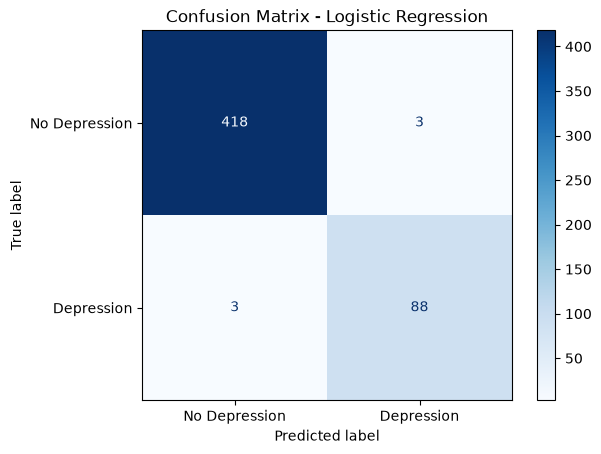

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Depression", "Depression"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Logistic Regression - Summary

The Logistic Regression model achieved excellent classification performance on the test dataset.

### Evaluation Results

- Accuracy: **98.83%**
- Precision: **96.70%**
- Recall: **96.70%**
- F1-Score: **96.70%**

### Confusion Matrix

|                | Predicted No | Predicted Yes |
|----------------|-------------:|--------------:|
| **Actual No**  | 418 | 3 |
| **Actual Yes** | 3 | 88 |

### Interpretation

- Correctly identified **418** non-depressed individuals.
- Correctly identified **88** depressed individuals.
- Misclassified only **6** out of **512** test samples.
- Only **3** depressed individuals were missed (False Negatives).
- Only **3** healthy individuals were incorrectly classified as depressed (False Positives).

Overall, the Logistic Regression model demonstrates excellent predictive performance and serves as a strong baseline for comparison with more advanced machine learning models.

### Decision Tree Terminology

A Decision Tree consists of three main components:

#### 1. Root Node

- The first node of the tree.
- Represents the initial decision based on the most informative feature.
- Every Decision Tree has only one root node.

#### 2. Decision Node

- An internal node that asks a question about a feature.
- Based on the answer, the data moves to the next branch.
- A tree can have multiple decision nodes.

#### 3. Leaf Node

- The final node of the tree.
- Represents the predicted class or output.
- Leaf nodes do not split further.

### How Does a Decision Tree Choose the Root Node?

A Decision Tree does not randomly select the root node.

Instead, it evaluates every feature and chooses the one that creates the best separation between the target classes.

The objective is to create the **purest possible groups** after each split.

For classification problems, the quality of a split is measured using criteria such as:

- **Gini Impurity** (default in scikit-learn)
- **Entropy (Information Gain)**

The feature that produces the purest child nodes becomes the root node.

### Gini Impurity

Gini Impurity measures how mixed the classes are within a node.

For binary classification:

\[
\text{Gini} = 1 - (P_{1}^{2} + P_{0}^{2})
\]

Where:

- \(P_1\) = Probability of class 1
- \(P_0\) = Probability of class 0

Interpretation:

- **Gini = 0** → Perfectly pure node (all samples belong to one class).
- **Higher Gini** → More mixed classes.
- A Decision Tree selects the split that results in the **lowest Gini Impurity**, producing the purest child nodes.

## Decision Tree Classifier

Scikit-learn provides the `DecisionTreeClassifier` class to build Decision Tree models for classification tasks.

The workflow is similar to Logistic Regression:

1. Import the classifier.
2. Create the model.
3. Train the model using `fit()`.
4. Make predictions using `predict()`.
5. Evaluate the model using metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

This consistent API makes it easy to switch between different machine learning algorithms.

### max_depth in Decision Trees

The `max_depth` parameter controls the maximum number of levels that a Decision Tree can grow.

- A **small `max_depth`** creates a simpler tree that may miss some patterns (underfitting).
- A **large `max_depth`** creates a more complex tree that may memorize the training data (overfitting).

Choosing an appropriate `max_depth` helps the model generalize better to unseen data.

### Overfitting and max_depth

A Decision Tree with a very large `max_depth` can become too complex.

It keeps creating new splits until it memorizes the training data instead of learning general patterns.

This results in:

- Very high training accuracy.
- Lower performance on unseen (test) data.

This problem is known as **overfitting**.

The `max_depth` parameter helps control the complexity of the Decision Tree and improves its ability to generalize.

# Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks.

For classification, it recursively splits the dataset based on the feature that minimizes impurity (Gini Impurity by default in scikit-learn).

In this project, we will train a Decision Tree model to predict whether a student is likely to experience depression.

In [16]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Creating the Decision Tree Model

We create a Decision Tree classifier using the default parameters.

By default:
- Criterion = Gini Impurity
- Splitter = Best
- max_depth = None (tree grows until stopping conditions are met)

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)

## Training the Model

The `fit()` method trains the Decision Tree using the training dataset.

The model learns decision rules from the input features to predict the target variable.

In [18]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Making Predictions

After training, the Decision Tree predicts the target values for the test dataset using the learned decision rules.

In [19]:
y_pred_dt = dt_model.predict(X_test)

## Evaluating the Decision Tree

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

These metrics help assess the classification performance of the Decision Tree.

In [20]:
# Decision Tree Evaluation

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-" * 35)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Performance
-----------------------------------
Accuracy : 0.9258
Precision: 0.7789
Recall   : 0.8132
F1 Score : 0.7957


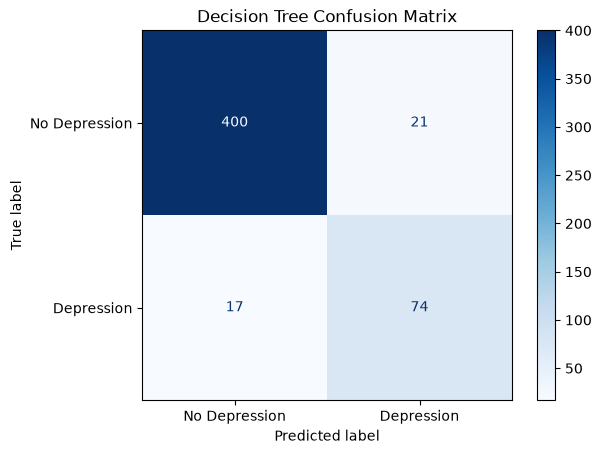

In [21]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Interpretation of the Decision Tree Results

The Decision Tree classifier achieved an accuracy of **92.58%**, indicating that it correctly classified most of the students in the test dataset.

From the confusion matrix:

- **True Negatives (TN): 400** students without depression were correctly classified.
- **True Positives (TP): 74** students with depression were correctly identified.
- **False Positives (FP): 21** students without depression were incorrectly predicted as having depression.
- **False Negatives (FN): 17** students with depression were incorrectly classified as not having depression.

The model achieved a **Precision of 77.89%**, meaning that approximately 78% of the students predicted as depressed were actually depressed.

The **Recall of 81.32%** indicates that the model successfully identified about 81% of the actual depression cases.

The **F1-Score of 79.57%** reflects a balanced performance between Precision and Recall.

Overall, the Decision Tree demonstrated good classification performance. However, compared with the Logistic Regression model, it produced lower Accuracy, Precision, Recall, and F1-Score, suggesting that Logistic Regression generalized better for this dataset.

# Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance.

Instead of relying on a single Decision Tree, Random Forest trains many Decision Trees on different subsets of the training data and combines their predictions.

For classification tasks, the final prediction is determined using **majority voting**.

Random Forest generally provides better accuracy, reduces overfitting, and improves generalization compared to a single Decision Tree.

## Bootstrap Sampling (Bagging)

Random Forest uses **Bootstrap Sampling**, also known as **Bagging (Bootstrap Aggregating)**.

Instead of training every Decision Tree on the entire dataset, each tree is trained on a different random sample of the original training data.

The samples are selected **with replacement**, meaning that:

- A sample may appear multiple times.
- Some samples may not appear in a particular training subset.

This introduces diversity among the Decision Trees, reducing overfitting and improving the model's ability to generalize.

## Working of Random Forest

Random Forest improves the performance of a single Decision Tree by introducing diversity among multiple trees.

The algorithm works in the following steps:

1. Create multiple bootstrap samples from the training dataset.
2. Train a separate Decision Tree on each bootstrap sample.
3. At every split, each tree considers only a random subset of the available features.
4. Each Decision Tree independently predicts the target class.
5. For classification, the final prediction is determined using **majority voting**.

This approach reduces overfitting, improves generalization, and usually achieves better predictive performance than a single Decision Tree.

# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance.

Unlike a single Decision Tree, Random Forest trains many Decision Trees using different bootstrap samples of the training data and random subsets of features.

For classification problems, the final prediction is determined using **majority voting**, where the class predicted by the majority of the trees becomes the final output.

Random Forest generally provides better accuracy, reduces overfitting, and improves generalization compared to a single Decision Tree.

In [22]:
from sklearn.ensemble import RandomForestClassifier

## Creating the Random Forest Model

A Random Forest classifier is created using the default parameters.

By default:

- Multiple Decision Trees are created.
- Bootstrap sampling is enabled.
- Random feature selection is used at each split.
- The final prediction is made using majority voting.

In [23]:
rf_model = RandomForestClassifier(random_state=42)

## Training the Model

The `fit()` method trains the Random Forest using the training dataset.

Each Decision Tree learns from a different bootstrap sample and random subset of features.

In [24]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Making Predictions

The trained Random Forest model predicts the target values for the test dataset using majority voting across all Decision Trees.

In [25]:
y_pred_rf = rf_model.predict(X_test)

## Model Evaluation

The Random Forest model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [26]:
# Random Forest Evaluation

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Performance
-----------------------------------
Accuracy : 0.9355
Precision: 0.9028
Recall   : 0.7143
F1 Score : 0.7975


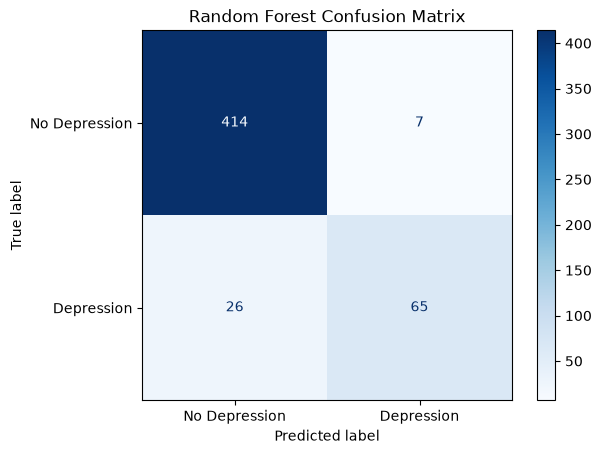

In [27]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Interpretation of the Random Forest Results

The Random Forest classifier achieved an accuracy of **93.55%**, correctly classifying most of the students in the test dataset.

From the confusion matrix:

- True Negatives (TN): 414
- True Positives (TP): 65
- False Positives (FP): 7
- False Negatives (FN): 26

The model achieved:

- Precision: **90.28%**
- Recall: **71.43%**
- F1-Score: **79.75%**

The Random Forest model produced very few false positives, resulting in high precision. However, it missed a larger number of actual depression cases, leading to a lower recall.

Compared with the Decision Tree, Random Forest improved Accuracy, Precision, and F1-Score. However, Logistic Regression remained the best-performing model, achieving higher Accuracy, Precision, Recall, and F1-Score on this dataset.

## Decision Boundary and Margin

A **Decision Boundary** is the line (or hyperplane in higher dimensions) that separates different classes.

In Support Vector Machine (SVM), many decision boundaries may correctly classify the training data. However, SVM selects the boundary that leaves the **maximum margin** between the two classes.

The **Margin** is the distance between the decision boundary and the nearest data points from each class.

A larger margin generally leads to better generalization and improved performance on unseen data.

## Support Vectors

The data points that are closest to the decision boundary are called **Support Vectors**.

These points play the most important role in determining the position of the decision boundary and the size of the margin.

Unlike some other machine learning algorithms, SVM primarily depends on these closest data points rather than the entire dataset to construct the optimal decision boundary.

The algorithm is named **Support Vector Machine** because these support vectors define and support the decision boundary.

## Hard Margin vs Soft Margin

Support Vector Machines can create two types of decision boundaries:

### Hard Margin

A Hard Margin SVM assumes that the data is perfectly separable. It attempts to classify every training sample correctly while maximizing the margin.

This approach works well only when the dataset has no overlap or noise.

### Soft Margin

In real-world datasets, perfect separation is rarely possible. Soft Margin SVM allows a small number of misclassified samples while still maximizing the margin.

This makes the model more robust to noisy and overlapping data and usually leads to better generalization on unseen data.

## Kernel Trick

Some datasets cannot be separated using a straight line. Such datasets are called **non-linearly separable**.

The **Kernel Trick** allows SVM to transform the data into a higher-dimensional feature space where a linear decision boundary can separate the classes.

Common kernels include:

- **Linear Kernel:** Suitable for linearly separable data.
- **Polynomial Kernel:** Creates curved decision boundaries.
- **RBF (Radial Basis Function) Kernel:** Handles complex non-linear relationships and is the default kernel in Scikit-learn.

Choosing the appropriate kernel depends on the characteristics of the dataset.

# Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks.

For classification, SVM finds the optimal decision boundary (hyperplane) that maximizes the margin between different classes.

The data points closest to the decision boundary are called **Support Vectors**, and they play the most important role in defining the boundary.

In this project, SVM is used to classify whether a student is likely to have depression based on the available features.

In [28]:
from sklearn.svm import SVC

## Creating the SVM Model

An SVM classifier is created using the default parameters.

By default:

- Kernel = RBF (Radial Basis Function)
- Regularization parameter (C) = 1.0
- Gamma = 'scale'

The RBF kernel is capable of learning complex non-linear decision boundaries.

In [29]:
svm_model = SVC(random_state=42)

## Training the Model

The `fit()` method trains the Support Vector Machine using the training dataset.

During training, the algorithm identifies the optimal decision boundary and the support vectors that maximize the margin between the classes.

In [30]:
svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


## Making Predictions

After training, the model predicts the depression status of students in the test dataset.

In [31]:
y_pred_svm = svm_model.predict(X_test)

## Model Evaluation

The performance of the Support Vector Machine is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [32]:
# Support Vector Machine Evaluation

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Support Vector Machine Performance")
print("-" * 40)
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Support Vector Machine Performance
----------------------------------------
Accuracy : 0.9082
Precision: 0.8548
Recall   : 0.5824
F1 Score : 0.6928


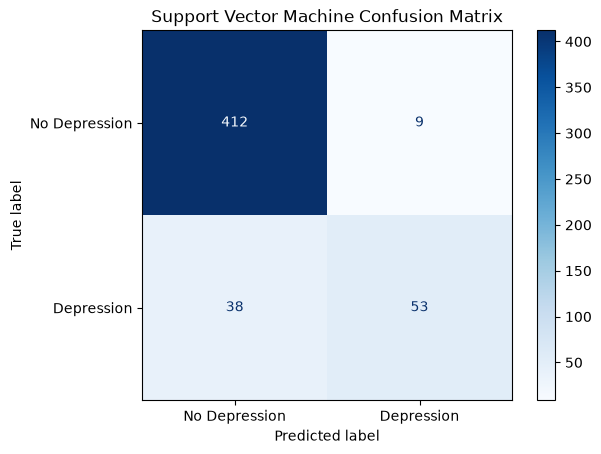

In [33]:
cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

## Interpretation of the Support Vector Machine Results

The Support Vector Machine classifier achieved an accuracy of **90.82%**, correctly classifying most students in the test dataset.

From the confusion matrix:

- True Negatives (TN): 412
- True Positives (TP): 53
- False Positives (FP): 9
- False Negatives (FN): 38

The model achieved:

- Precision: **85.48%**
- Recall: **58.24%**
- F1-Score: **69.28%**

The SVM model produced relatively few false positives, resulting in good precision. However, it failed to identify a considerable number of actual depression cases, leading to a low recall.

Compared with the other baseline models, SVM showed the lowest overall performance on this dataset. Logistic Regression remained the best-performing model, achieving the highest Accuracy, Precision, Recall, and F1-Score.

# Feature Scaling

Feature scaling is an important preprocessing step for machine learning algorithms that rely on distance calculations or optimization techniques.

Algorithms such as Logistic Regression and Support Vector Machine (SVM) benefit from scaling because it places all features on a similar numerical scale.

Tree-based algorithms such as Decision Tree and Random Forest do not require feature scaling because they split data based on feature thresholds rather than distances.

In this project, StandardScaler is applied only to Logistic Regression and SVM before hyperparameter tuning.

In [34]:
from sklearn.preprocessing import StandardScaler

## Applying StandardScaler

The dataset is split into training and testing sets before scaling to prevent **data leakage**.

The scaler is fitted only on the training data and then applied to both the training and testing datasets.

This ensures that information from the test dataset is not used during model training.

In [35]:
scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression (After Feature Scaling)

To evaluate the impact of feature scaling, Logistic Regression is retrained using the standardized training dataset.

Since Logistic Regression is an optimization-based algorithm, scaling the features can improve convergence and ensure that all features contribute equally during training.

The performance of the scaled model will be compared with the original Logistic Regression model to determine whether feature scaling improves predictive performance.

In [37]:
lr_scaled_model = LogisticRegression(random_state=42)

## Training the Scaled Logistic Regression Model

The model is trained using the standardized training dataset generated by StandardScaler.

In [38]:
lr_scaled_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

## Making Predictions

The trained Logistic Regression model predicts the depression status of students in the standardized test dataset.

In [39]:
y_pred_lr_scaled = lr_scaled_model.predict(X_test_scaled)

## Model Evaluation

The scaled Logistic Regression model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The results will be compared with the original Logistic Regression model.

In [40]:
# Scaled Logistic Regression Evaluation

lr_scaled_accuracy = accuracy_score(y_test, y_pred_lr_scaled)
lr_scaled_precision = precision_score(y_test, y_pred_lr_scaled)
lr_scaled_recall = recall_score(y_test, y_pred_lr_scaled)
lr_scaled_f1 = f1_score(y_test, y_pred_lr_scaled)

print("Scaled Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {lr_scaled_accuracy:.4f}")
print(f"Precision: {lr_scaled_precision:.4f}")
print(f"Recall   : {lr_scaled_recall:.4f}")
print(f"F1 Score : {lr_scaled_f1:.4f}")

Scaled Logistic Regression Performance
----------------------------------------
Accuracy : 0.9688
Precision: 0.8866
Recall   : 0.9451
F1 Score : 0.9149


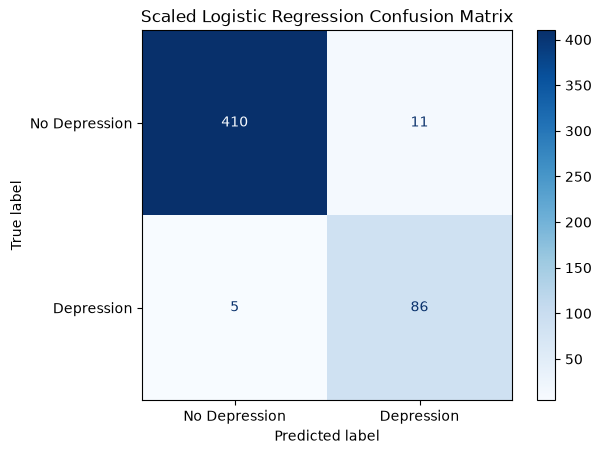

In [41]:
cm = confusion_matrix(y_test, y_pred_lr_scaled)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")
plt.title("Scaled Logistic Regression Confusion Matrix")
plt.show()

## Interpretation of the Scaled Logistic Regression Results

The scaled Logistic Regression model achieved an accuracy of **96.88%**.

Compared with the original Logistic Regression model, feature scaling resulted in slightly lower Accuracy, Precision, Recall, and F1-Score.

This behavior can be explained by the characteristics of the dataset. Most predictor variables were already encoded into binary, ordinal, or one-hot encoded values, resulting in relatively similar feature ranges.

Since Logistic Regression was already performing exceptionally well on the original encoded dataset, applying StandardScaler did not provide additional benefits and slightly reduced the overall predictive performance.

This experiment demonstrates that feature scaling is not guaranteed to improve every model. The effectiveness of scaling depends on both the algorithm and the characteristics of the dataset.

# Support Vector Machine (After Feature Scaling)

To evaluate the effect of feature scaling, the Support Vector Machine (SVM) model is retrained using the standardized dataset.

SVM is a distance-based algorithm that is highly sensitive to the scale of input features. Standardizing the features ensures that all variables contribute equally when constructing the optimal decision boundary.

The performance of the scaled SVM model will be compared with the original SVM model to evaluate the impact of feature scaling.

In [42]:
svm_scaled_model = SVC(random_state=42)

## Training the Scaled SVM Model

The Support Vector Machine is trained using the standardized training dataset produced by StandardScaler.

The model identifies the optimal decision boundary using the scaled feature values.

In [43]:
svm_scaled_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


## Making Predictions

The trained SVM model predicts the depression status of students in the standardized test dataset.

In [44]:
y_pred_svm_scaled = svm_scaled_model.predict(X_test_scaled)

## Model Evaluation

The scaled Support Vector Machine is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The results will be compared with the original SVM model.

In [45]:
# Scaled Support Vector Machine Evaluation

svm_scaled_accuracy = accuracy_score(y_test, y_pred_svm_scaled)
svm_scaled_precision = precision_score(y_test, y_pred_svm_scaled)
svm_scaled_recall = recall_score(y_test, y_pred_svm_scaled)
svm_scaled_f1 = f1_score(y_test, y_pred_svm_scaled)

print("Scaled Support Vector Machine Performance")
print("-" * 45)
print(f"Accuracy : {svm_scaled_accuracy:.4f}")
print(f"Precision: {svm_scaled_precision:.4f}")
print(f"Recall   : {svm_scaled_recall:.4f}")
print(f"F1 Score : {svm_scaled_f1:.4f}")

Scaled Support Vector Machine Performance
---------------------------------------------
Accuracy : 0.9238
Precision: 0.9194
Recall   : 0.6264
F1 Score : 0.7451


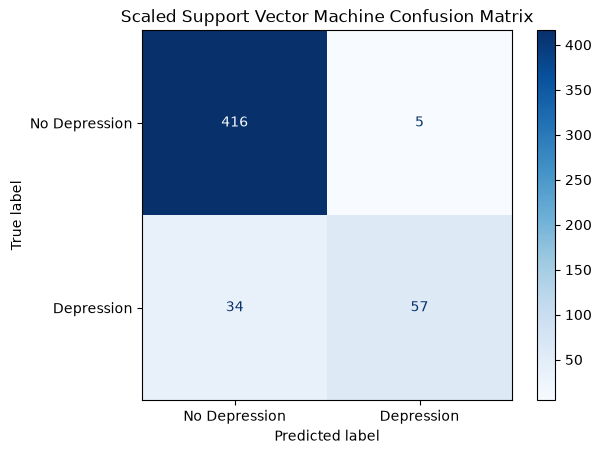

In [46]:
cm = confusion_matrix(y_test, y_pred_svm_scaled)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")
plt.title("Scaled Support Vector Machine Confusion Matrix")
plt.show()

## Interpretation of the Scaled Support Vector Machine Results

The scaled Support Vector Machine achieved an accuracy of **92.38%**.

Compared with the original SVM model, feature scaling improved the overall predictive performance.

From the confusion matrix:

- True Negatives (TN): 416
- True Positives (TP): 57
- False Positives (FP): 5
- False Negatives (FN): 34

The model achieved:

- Precision: **91.94%**
- Recall: **62.64%**
- F1-Score: **74.51%**

The improvement demonstrates the importance of feature scaling for Support Vector Machines. Since SVM relies on distance calculations to determine the optimal decision boundary, scaling allows all features to contribute equally during training.

Although the scaled SVM performed better than the original SVM, it still did not outperform the original Logistic Regression model on this dataset.

# Model Comparison and Selection

Multiple machine learning models were trained and evaluated to identify the most suitable algorithm for predicting depression.

Both baseline and scaled models were compared using:

- Accuracy
- Precision
- Recall
- F1-Score

The objective of this comparison is to identify the best-performing model before applying hyperparameter tuning.

In [47]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Scaled)",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "Support Vector Machine (Scaled)"
    ],

    "Scaling": [
        "No",
        "Yes",
        "No",
        "No",
        "No",
        "Yes"
    ],

    "Accuracy": [
        lr_accuracy,
        lr_scaled_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        svm_scaled_accuracy
    ],

    "Precision": [
        lr_precision,
        lr_scaled_precision,
        dt_precision,
        rf_precision,
        svm_precision,
        svm_scaled_precision
    ],

    "Recall": [
        lr_recall,
        lr_scaled_recall,
        dt_recall,
        rf_recall,
        svm_recall,
        svm_scaled_recall
    ],

    "F1 Score": [
        lr_f1,
        lr_scaled_f1,
        dt_f1,
        rf_f1,
        svm_f1,
        svm_scaled_f1
    ]
})

comparison_df = comparison_df.round(4)
comparison_df

,Model,Scaling,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,No,0.9883,0.9670,0.9670,0.9670
1,Logistic Regression (Scaled),Yes,0.9688,0.8866,0.9451,0.9149
2,Decision Tree,No,0.9258,0.7789,0.8132,0.7957
3,Random Forest,No,0.9355,0.9028,0.7143,0.7975
4,Support Vector Machine,No,0.9082,0.8548,0.5824,0.6928
5,Support Vector Machine (Scaled),Yes,0.9238,0.9194,0.6264,0.7451


## Model Performance Comparison

The performance of all trained machine learning models was compared using four evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score

The comparison also includes the effect of feature scaling on Logistic Regression and Support Vector Machine models.

The results are summarized below.

## Model Selection

The comparison of all machine learning models provides the following insights:

### Logistic Regression

The original Logistic Regression model achieved the best overall performance with:

- Accuracy: **98.83%**
- Precision: **96.70%**
- Recall: **96.70%**
- F1-Score: **96.70%**

This indicates that Logistic Regression generalized extremely well on the dataset without requiring feature scaling.

---

### Logistic Regression (Scaled)

After applying StandardScaler, the performance of Logistic Regression decreased slightly.

Although recall increased marginally, the reduction in precision and overall F1-score indicates that scaling was unnecessary for this dataset because the features were already encoded and had similar numerical ranges.

---

### Decision Tree

The Decision Tree classifier produced acceptable results but showed lower performance than Logistic Regression.

Decision Trees are more prone to overfitting, which may explain the lower generalization performance on the test data.

---

### Random Forest

Random Forest improved upon the Decision Tree by reducing overfitting through ensemble learning.

It achieved high precision but lower recall, indicating that while positive predictions were usually correct, some depression cases were missed.

---

### Support Vector Machine

The baseline SVM model produced the weakest performance among all evaluated models.

This is expected because Support Vector Machines are sensitive to feature scaling.

---

### Support Vector Machine (Scaled)

Applying StandardScaler improved the SVM model across all evaluation metrics.

Although scaling significantly improved SVM performance, it still did not outperform the original Logistic Regression model.

---

### Final Model Selection

Based on the experimental results, the following models were selected for hyperparameter tuning:

- Logistic Regression
- Random Forest
- Support Vector Machine (Scaled)

Among all evaluated models, the original Logistic Regression model demonstrated the best balance between Accuracy, Precision, Recall, and F1-Score, making it the strongest baseline model for depression prediction.

# Hyperparameter Tuning

Machine learning algorithms contain **hyperparameters**, which are configuration values set **before** the training process begins.

If we do not specify these values, Scikit-learn automatically uses its **default hyperparameter values**.

For example:

```python
RandomForestClassifier()
```

internally uses default values such as:

- `n_estimators = 100`
- `criterion = "gini"`
- `max_depth = None`
- `min_samples_split = 2`

These default values may not always produce the best model for every dataset.

**Hyperparameter Tuning** is the process of finding the optimal combination of hyperparameter values to improve the model's performance.

## Parameters vs Hyperparameters

Machine learning models contain two types of values:

### Hyperparameters

Hyperparameters are configuration values that are set **before training** the model.

These values are chosen by the developer and control how the learning algorithm works.

Examples:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `learning_rate`
- `C`
- `kernel`

---

### Parameters

Parameters are values that the model **learns automatically during training** from the dataset.

These values cannot be manually specified because they are estimated by the learning algorithm.

Examples:

- Split points in Decision Trees
- Coefficients in Logistic Regression
- Weights in Neural Networks
- Support vectors in Support Vector Machine

---

### Difference

| Hyperparameters | Parameters |
|-----------------|------------|
| Set before training | Learned during training |
| Controlled by the developer | Learned by the model |
| Control the learning process | Represent the learned knowledge |

## Why Does Hyperparameter Tuning Improve Performance?

Hyperparameters control how a machine learning algorithm learns from the training data.

Changing hyperparameter values changes the behavior and complexity of the model.

For example, in a Random Forest model:

- Increasing `n_estimators` creates more decision trees, which can improve stability and reduce variance.
- Increasing `max_depth` allows trees to learn more complex patterns but may increase the risk of overfitting.

Since different datasets have different characteristics, there is no single combination of hyperparameters that works best for every problem.

Hyperparameter tuning is the process of finding the combination of hyperparameters that produces the best model performance on a given dataset.

# GridSearchCV

GridSearchCV is a hyperparameter tuning technique provided by Scikit-learn.

It automatically trains multiple models using different combinations of hyperparameter values and evaluates each combination.

The model with the best evaluation score is selected as the optimal model.

---

## Why use GridSearchCV?

Instead of manually trying different hyperparameter values, GridSearchCV automates the entire process.

It:

- Trains multiple models
- Evaluates every combination
- Compares the results
- Selects the best-performing model

---

## Example

Suppose we want to tune:

```python
n_estimators = [100, 200]
max_depth = [5, 10]
criterion = ["gini", "entropy"]
```

GridSearchCV will evaluate all possible combinations:

| n_estimators | max_depth | criterion |
|--------------|-----------|-----------|
|100|5|gini|
|100|5|entropy|
|100|10|gini|
|100|10|entropy|
|200|5|gini|
|200|5|entropy|
|200|10|gini|
|200|10|entropy|

After evaluating every combination, it returns the best-performing model.

# Cross Validation

Cross Validation is a model evaluation technique used to estimate how well a machine learning model generalizes to unseen data.

The most commonly used method is **K-Fold Cross Validation**.

---

## How K-Fold Cross Validation Works

1. Split the training dataset into **K equal parts (folds)**.
2. Train the model using **K-1 folds**.
3. Use the remaining fold for validation.
4. Repeat the process until every fold has been used as the validation set exactly once.
5. Compute the average performance across all folds.

---

## Example: 5-Fold Cross Validation

Suppose the training dataset contains **1000 samples**.

The dataset is divided into **5 equal folds**:

- Fold 1 → 200 samples
- Fold 2 → 200 samples
- Fold 3 → 200 samples
- Fold 4 → 200 samples
- Fold 5 → 200 samples

The model is trained **5 times**:

| Iteration | Training Folds | Validation Fold |
|-----------|----------------|-----------------|
| 1 | 2, 3, 4, 5 | 1 |
| 2 | 1, 3, 4, 5 | 2 |
| 3 | 1, 2, 4, 5 | 3 |
| 4 | 1, 2, 3, 5 | 4 |
| 5 | 1, 2, 3, 4 | 5 |

The final performance is calculated as the **average of all five validation scores**.

---

## Why Use Cross Validation?

- Produces a more reliable estimate of model performance.
- Reduces dependence on a single train-validation split.
- Helps select better hyperparameters during GridSearchCV.
- Reduces the risk of choosing a model that performs well only on one particular split.

# Hyperparameter Tuning

The baseline machine learning models produced strong performance; however, the default hyperparameter values provided by Scikit-learn may not be optimal for this dataset.

Hyperparameter tuning is performed to identify the combination of hyperparameters that produces the best model performance.

GridSearchCV with 5-Fold Cross Validation is used to automatically evaluate multiple hyperparameter combinations and select the best-performing model.

In [48]:
from sklearn.model_selection import GridSearchCV

## Hyperparameter Search Space

Before performing hyperparameter tuning, we define a **parameter grid**.

A parameter grid contains different values of hyperparameters that GridSearchCV will evaluate.

For each possible combination:

1. The model is trained.
2. 5-Fold Cross Validation is performed.
3. The average validation score is calculated.

The combination with the highest average validation score is selected as the best model.

In [49]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

In [50]:
lr_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=lr_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [51]:
lr_grid.fit(X_train, y_train)

d:\MindSense-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\MindSense-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity

In [52]:
print("Best Parameters:")
print(lr_grid.best_params_)

Best Parameters:
{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [53]:
print("Best Cross Validation F1 Score:")
print(lr_grid.best_score_)

Best Cross Validation F1 Score:
0.9599168483497561


In [54]:
best_lr = lr_grid.best_estimator_

## Logistic Regression Hyperparameter Tuning

GridSearchCV was used to optimize the Logistic Regression model by evaluating multiple combinations of hyperparameters using **5-Fold Cross Validation**.

### Best Hyperparameters

- **C = 100**
- **Penalty = L2**
- **Solver = lbfgs**

The tuned model achieved an average Cross Validation **F1-Score of 95.99%**, indicating strong and consistent performance across multiple validation folds.

A larger value of **C** reduced the amount of regularization, allowing the model to learn the underlying patterns in the dataset more effectively.

The **L2 regularization** improved generalization while reducing the risk of overfitting.

The **lbfgs** optimization algorithm produced better results than the alternative solver evaluated during the hyperparameter search.

In [55]:
# Predictions using the tuned model

y_pred_best_lr = best_lr.predict(X_test)

In [56]:
best_lr_accuracy = accuracy_score(y_test, y_pred_best_lr)
best_lr_precision = precision_score(y_test, y_pred_best_lr)
best_lr_recall = recall_score(y_test, y_pred_best_lr)
best_lr_f1 = f1_score(y_test, y_pred_best_lr)

print("Tuned Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {best_lr_accuracy:.4f}")
print(f"Precision: {best_lr_precision:.4f}")
print(f"Recall   : {best_lr_recall:.4f}")
print(f"F1 Score : {best_lr_f1:.4f}")

Tuned Logistic Regression Performance
----------------------------------------
Accuracy : 0.9824
Precision: 0.9362
Recall   : 0.9670
F1 Score : 0.9514


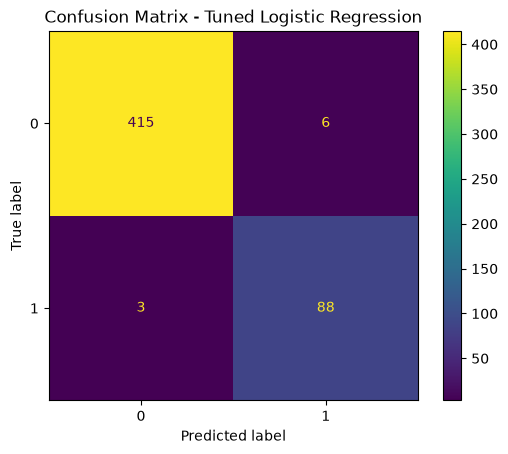

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_lr, X_test, y_test)
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

## Evaluation of Tuned Logistic Regression

The optimized Logistic Regression model was evaluated on the unseen test dataset.

### Test Performance

- Accuracy: **98.24%**
- Precision: **93.62%**
- Recall: **96.70%**
- F1-Score: **95.14%**

### Comparison with the Baseline Model

Although GridSearchCV identified a better set of hyperparameters during cross-validation, the tuned model did not outperform the original Logistic Regression model on the test dataset.

The tuned model maintained the same recall but produced more false positive predictions, resulting in lower precision, lower accuracy, and a lower F1-score.

This indicates that the default Logistic Regression configuration already generalized extremely well for this dataset.

Therefore, the original Logistic Regression model was retained as the preferred model.

# Random Forest Hyperparameter Tuning

Random Forest is an ensemble learning algorithm that contains several important hyperparameters that influence its performance.

GridSearchCV is used to evaluate different combinations of these hyperparameters using 5-Fold Cross Validation.

The objective is to identify the combination that produces the highest F1-Score while maintaining good generalization performance.

In [58]:
RandomForestClassifier(
    n_estimators=100,
    max_depth=5
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [59]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

## Random Forest Search Space

The following hyperparameters are optimized:

- **n_estimators** → Number of trees in the forest.
- **max_depth** → Maximum depth of each tree.
- **min_samples_split** → Minimum number of samples required to split a node.
- **min_samples_leaf** → Minimum number of samples required in a leaf node.

GridSearchCV evaluates every possible combination of these values using **5-Fold Cross Validation** and selects the combination with the highest average F1-Score.

In [60]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [61]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [62]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [63]:
print("Best Cross Validation F1 Score:")
print(rf_grid.best_score_)

Best Cross Validation F1 Score:
0.7532995691019669


In [64]:
best_rf = rf_grid.best_estimator_

## Random Forest Hyperparameter Tuning

GridSearchCV was applied to optimize the Random Forest classifier using **5-Fold Cross Validation**.

### Best Hyperparameters

- **n_estimators = 200**
- **max_depth = None**
- **min_samples_split = 2**
- **min_samples_leaf = 1**

The optimized model achieved an average Cross Validation **F1-Score of 75.33%**.

The results indicate that increasing the number of trees from the default value improved the model during cross-validation, while allowing unrestricted tree depth produced the best validation performance for this dataset.

In [65]:
# Predictions using the tuned Random Forest

y_pred_best_rf = best_rf.predict(X_test)

In [66]:
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
best_rf_precision = precision_score(y_test, y_pred_best_rf)
best_rf_recall = recall_score(y_test, y_pred_best_rf)
best_rf_f1 = f1_score(y_test, y_pred_best_rf)

print("Tuned Random Forest Performance")
print("-" * 40)
print(f"Accuracy : {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall   : {best_rf_recall:.4f}")
print(f"F1 Score : {best_rf_f1:.4f}")

Tuned Random Forest Performance
----------------------------------------
Accuracy : 0.9453
Precision: 0.9200
Recall   : 0.7582
F1 Score : 0.8313


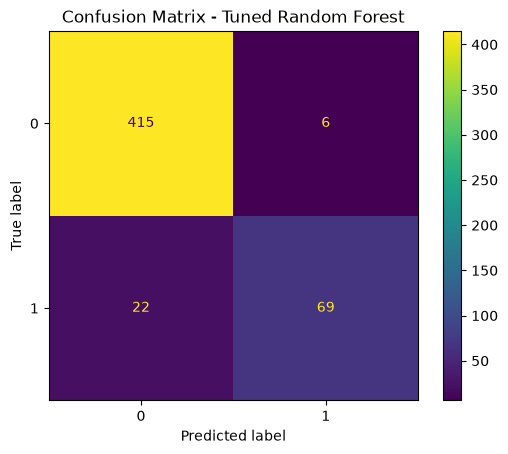

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

## Evaluation of Tuned Random Forest

The optimized Random Forest model was evaluated on the unseen test dataset.

### Test Performance

- Accuracy: **94.53%**
- Precision: **92.00%**
- Recall: **75.82%**
- F1-Score: **83.13%**

### Comparison with the Baseline Model

Hyperparameter tuning improved the Random Forest model across all evaluation metrics.

Compared with the baseline model, the tuned Random Forest:

- Increased Accuracy
- Increased Precision
- Increased Recall
- Increased F1-Score

The tuned model correctly identified more positive depression cases while reducing both false positive and false negative predictions.

These results demonstrate that hyperparameter tuning significantly improved the generalization performance of the Random Forest classifier.

Therefore, the tuned Random Forest model is selected as the final Random Forest model for further comparison.

# Support Vector Machine Hyperparameter Tuning

Support Vector Machine (SVM) is highly sensitive to the choice of hyperparameters.

Unlike tree-based models, SVM performance is significantly influenced by parameters such as the regularization parameter (**C**) and the kernel coefficient (**gamma**).

GridSearchCV with 5-Fold Cross Validation is used to determine the optimal combination of hyperparameters for the scaled Support Vector Machine model.

In [68]:
svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf"]
}

## SVM Search Space

The following hyperparameters are optimized:

- **C** → Controls the regularization strength.
- **gamma** → Determines the influence of individual training samples.
- **kernel** → Specifies the decision boundary used by the classifier.

GridSearchCV evaluates every possible combination using **5-Fold Cross Validation** and selects the model with the highest average F1-Score.

In [69]:
svm_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svm_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [70]:
svm_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information p

In [71]:
print("Best Parameters:")
print(svm_grid.best_params_)

Best Parameters:
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [72]:
print("Best Cross Validation F1 Score:")
print(svm_grid.best_score_)

Best Cross Validation F1 Score:
0.8250346302601177


In [73]:
best_svm = svm_grid.best_estimator_

In [74]:
y_pred_best_svm = best_svm.predict(X_test_scaled)

In [75]:
best_svm_accuracy = accuracy_score(y_test, y_pred_best_svm)
best_svm_precision = precision_score(y_test, y_pred_best_svm)
best_svm_recall = recall_score(y_test, y_pred_best_svm)
best_svm_f1 = f1_score(y_test, y_pred_best_svm)

print("Tuned Support Vector Machine Performance")
print("-" * 45)
print(f"Accuracy : {best_svm_accuracy:.4f}")
print(f"Precision: {best_svm_precision:.4f}")
print(f"Recall   : {best_svm_recall:.4f}")
print(f"F1 Score : {best_svm_f1:.4f}")

Tuned Support Vector Machine Performance
---------------------------------------------
Accuracy : 0.9375
Precision: 0.8554
Recall   : 0.7802
F1 Score : 0.8161


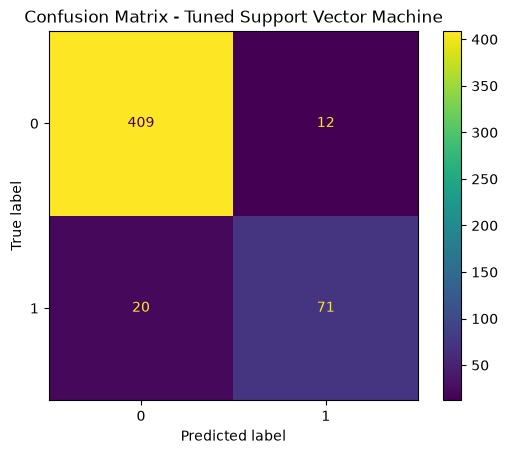

In [76]:
ConfusionMatrixDisplay.from_estimator(
    best_svm,
    X_test_scaled,
    y_test
)

plt.title("Confusion Matrix - Tuned Support Vector Machine")
plt.show()

## Evaluation of Tuned Support Vector Machine

The optimized Support Vector Machine (SVM) model was evaluated on the unseen test dataset.

### Test Performance

- Accuracy: **93.75%**
- Precision: **85.54%**
- Recall: **78.02%**
- F1-Score: **81.61%**

### Comparison with the Baseline Model

Hyperparameter tuning significantly improved the recall and F1-score of the Support Vector Machine model.

The tuned model correctly identified more depression cases and substantially reduced the number of false negative predictions.

Although precision decreased due to an increase in false positive predictions, the improvement in recall resulted in a higher overall F1-score.

For mental health screening applications, reducing false negatives is particularly important because it minimizes the likelihood of failing to identify individuals who may require further clinical assessment.

Therefore, the tuned SVM model is selected as the final Support Vector Machine model.

# Final Model Selection

Several machine learning algorithms were trained, evaluated, and optimized using hyperparameter tuning.

The models were compared using Accuracy, Precision, Recall, and F1-Score.

## Summary

- Logistic Regression achieved the highest overall performance without requiring hyperparameter tuning.
- Hyperparameter tuning improved both Random Forest and Support Vector Machine models.
- Although the tuned models demonstrated noticeable improvements, they did not surpass the baseline Logistic Regression model on the unseen test dataset.

## Final Selected Model

**Logistic Regression** was selected as the final prediction model for the MindSense AI framework because it achieved the best balance across all evaluation metrics.

### Final Performance

- Accuracy: **98.83%**
- Precision: **96.70%**
- Recall: **96.70%**
- F1-Score: **96.70%**

These results indicate that Logistic Regression generalized exceptionally well and provides the most reliable performance for depression prediction using the available dataset.

The selected model will be used in the subsequent stages of the project, including model evaluation, explainable AI, and deployment.